# High-Performance LLM Inference Engine on Edge GPUs
**KV-Cache Optimization + CUDA Kernel Fusion + Decoding Acceleration**

Target: NVIDIA Jetson Orin Nano (Ampere sm_87)

This notebook is the top-level driver. All heavy logic lives in `.py` modules.

## 0. Environment Setup

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())  # so Python finds runtime/, memory/, etc.
import zipfile
with zipfile.ZipFile('/content/test.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print('Unzipped test.zip to /content/')
# Verify that the files are now accessible
print('Listing contents of /content/ directory:')
!ls -F /content/

Unzipped test.zip to /content/
Listing contents of /content/ directory:
benchmarks/  memory/	 results/  sample_data/  test.zip
kernels/     profiling/  runtime/  serving/


In [1]:
import importlib

import runtime.model_loader as model_loader
import memory.kv_manager as kv_manager
import runtime.decoder as decoder_mod
import benchmarks.latency_test as latency_test
import benchmarks.throughput_test as throughput_test
import profiling.roofline_analysis as roofline_analysis

importlib.reload(model_loader)
importlib.reload(kv_manager)
importlib.reload(decoder_mod)
importlib.reload(latency_test)
importlib.reload(throughput_test)
importlib.reload(roofline_analysis)

from runtime.model_loader import load_model, print_model_summary
from memory.kv_manager import KVCacheManager
from runtime.decoder import Decoder
from benchmarks.latency_test import run_latency_benchmark, plot_latency_results
from benchmarks.throughput_test import run_throughput_benchmark, plot_throughput_results
from profiling.roofline_analysis import RooflineAnalyzer

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Load Model

In [3]:


MODEL_NAME = "facebook/opt-1.3b"   # swap for any 1B-3B HF model
DEVICE     = "cuda"
DTYPE      = "float16"             # fp16 for Ampere Tensor Cores

model, tokenizer, config = load_model(MODEL_NAME, device=DEVICE, dtype=DTYPE)
print_model_summary(model, config)

[model_loader] Loading 'facebook/opt-1.3b' → cuda (float16)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[model_loader] Model loaded. Parameters: 1.42B
  Model            : OPTForCausalLM
  Hidden size      : 2048
  Layers           : 24
  Attention heads  : 32
  Vocab size       : 50272
  Max position emb : 2048
  Total params     : 1.42B


## 2. Initialise KV-Cache Manager

In [4]:

kv_manager = KVCacheManager(
    num_layers   = config.num_hidden_layers,
    num_heads    = config.num_attention_heads,
    head_dim     = config.hidden_size // config.num_attention_heads,
    block_size   = 16,          # tokens per KV block
    max_blocks   = 2048,         # total GPU blocks in pool
    dtype        = DTYPE,
    device       = DEVICE,
)
print(kv_manager)

KVCacheManager(layers=24, heads=32, head_dim=64, block_size=16, max_blocks=2048, pool=6442.5MB, alloc=0, util=0.0%)


## 3. Build Scheduler

In [5]:
from runtime.scheduler import DynamicBatchScheduler

scheduler = DynamicBatchScheduler(
    max_batch_size     = 8,
    max_sequence_len   = 2048,
    prefill_budget_ms  = 200,   # max ms to spend in prefill before decode
)
print(scheduler)

DynamicBatchScheduler(max_batch=8, max_seq=2048, prefill_budget=200ms)


## 4. Build Decoder

In [6]:

decoder = Decoder(
    model       = model,
    tokenizer   = tokenizer,
    kv_manager  = kv_manager,
    scheduler   = scheduler,
    device      = DEVICE,
)
print(decoder)

Decoder(model=OPTForCausalLM, device=cuda, sync_kv_pool=True)


## 5. Single-Request Inference

In [7]:
prompt = "Explain the role of KV-cache in transformer inference:"

output = decoder.generate(
    prompt         = prompt,
    max_new_tokens = 128,
    temperature    = 0.7,
    top_p          = 0.9,
    streaming      = True,
)
print("\n--- Full output ---\n", output)



KV-cache is a small KVM-based virtual machine, which can be run in a single host and in multiple host nodes. This VM is a simple implementation of a VM with some semantics to understand what happens when you run it.

The virtual machine is in the form of a tree structure, where nodes are hosts. The tree structure is a good model for the machine.

The VM is fully statically typed and contains no exceptions. It is a type-safe VM, but it is not type-safe for programs that need to run on it.

The VM is a SIMD-like
--- Full output ---
 Explain the role of KV-cache in transformer inference:

KV-cache is a small KVM-based virtual machine, which can be run in a single host and in multiple host nodes. This VM is a simple implementation of a VM with some semantics to understand what happens when you run it.

The virtual machine is in the form of a tree structure, where nodes are hosts. The tree structure is a good model for the machine.

The VM is fully statically typed and contains no excepti

## 6. Batched Inference

In [8]:
prompts = [
    "What is CUDA kernel fusion?",
    "Describe paged KV-cache memory management.",
    "How does speculative decoding reduce latency?",
    "What is the roofline model in GPU performance analysis?",
]

results = decoder.generate_batch(
    prompts        = prompts,
    max_new_tokens = 64,
    temperature    = 0.8,
)
for p, r in zip(prompts, results):
    print(f"Q: {p}\nA: {r}\n{'-'*60}")

Q: What is CUDA kernel fusion?
A: What is CUDA kernel fusion??
A closed source driver for Nvidia GPUs
------------------------------------------------------------
Q: Describe paged KV-cache memory management.
A: Describe paged KV-cache memory management. The difference between a paged cache and an unbuffered cache?

The difference between a paged cache and an unbuffered cache is that an unbuffered cache is designed to be used in situations where the cache is unavailable for some reason. A paged cache is designed to be used in situations where
------------------------------------------------------------
Q: How does speculative decoding reduce latency?
A: How does speculative decoding reduce latency?
Well it seems to reduce the latency of the output of the arduino. It is basically a clever way of reducing the CPU time used to process the data from the arduino. It reduces the amount of time needed to process the data, which will improve the speed of the code.
-----------------------------

## 7. Latency Benchmark

  seq_len=  128  batch_size=1 ... e2e=763.8ms  tok=23.87ms
  seq_len=  128  batch_size=2 ... e2e=746.0ms  tok=11.66ms
  seq_len=  128  batch_size=4 ... e2e=1034.3ms  tok=8.08ms
  seq_len=  128  batch_size=8 ... e2e=1630.1ms  tok=6.37ms
  seq_len=  256  batch_size=1 ... e2e=888.4ms  tok=27.76ms
  seq_len=  256  batch_size=2 ... e2e=1117.7ms  tok=17.46ms
  seq_len=  256  batch_size=4 ... e2e=1635.7ms  tok=12.78ms
  seq_len=  256  batch_size=8 ... e2e=2703.3ms  tok=10.56ms
  seq_len=  512  batch_size=1 ... e2e=1117.7ms  tok=34.93ms
  seq_len=  512  batch_size=2 ... e2e=1586.5ms  tok=24.79ms
  seq_len=  512  batch_size=4 ... e2e=2610.4ms  tok=20.39ms
  seq_len=  512  batch_size=8 ... e2e=4597.6ms  tok=17.96ms
  seq_len= 1024  batch_size=1 ... e2e=1578.6ms  tok=49.33ms
  seq_len= 1024  batch_size=2 ... e2e=2528.4ms  tok=39.51ms
  seq_len= 1024  batch_size=4 ... e2e=4520.1ms  tok=35.31ms
  seq_len= 1024  batch_size=8 ... e2e=8403.2ms  tok=32.82ms
  Results saved → results/csv_logs/latency_re

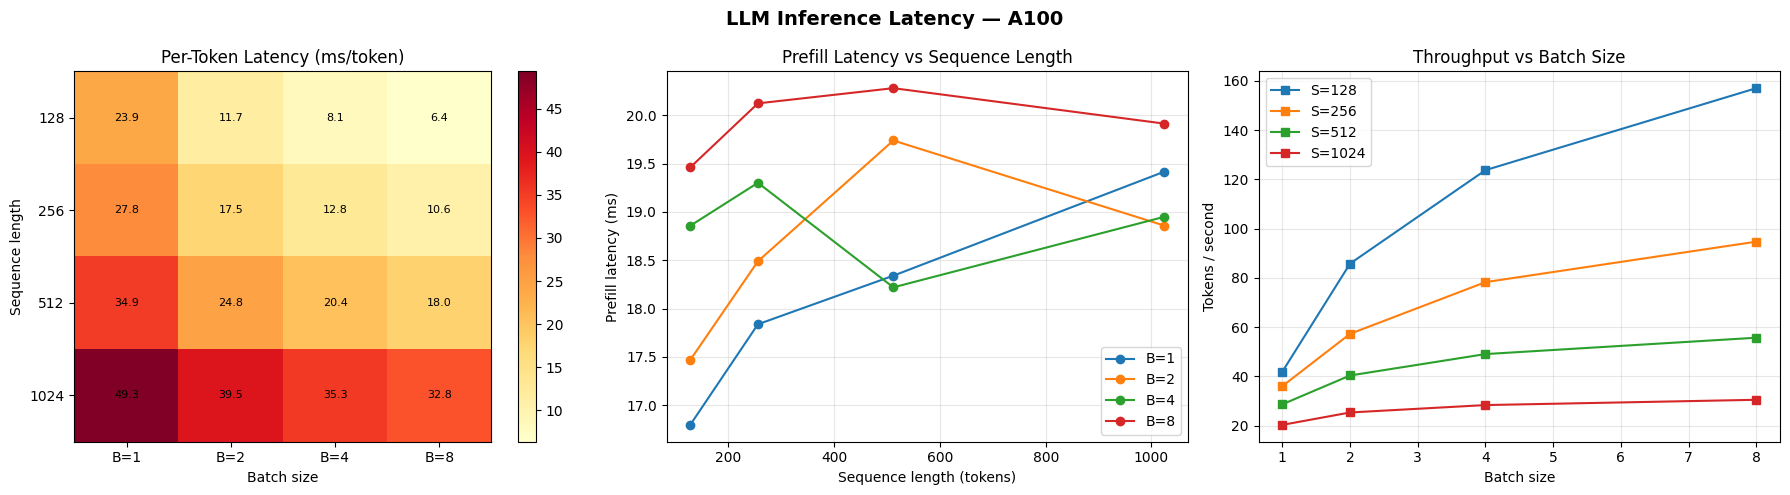

Plots saved to results/plots/latency_benchmark.png


In [9]:


latency_results = run_latency_benchmark(
    decoder         = decoder,
    seq_lengths     = [128, 256, 512, 1024],
    batch_sizes     = [1, 2, 4, 8],
    num_trials      = 5,
    warmup_trials   = 2,
    max_new_tokens  = 32,
    skip_on_oom     = True,
)
plot_latency_results(latency_results)

## 8. Throughput Benchmark

In [10]:
import gc
import torch

# 1. Clear out any global variables holding old engine instances if they exist
if 'decoder' in globals():
    del decoder
if 'kv_manager' in globals():
    del kv_manager

# 2. Force Python's garbage collector to find and destroy orphaned objects
gc.collect()

# 3. Force PyTorch to release its held VRAM cache back to the GPU operating system
torch.cuda.empty_cache()

  batch_size=1  seq_len=512  [30s window]
    → 37.0 tok/s  |  0.6 req/s  |  lat_mean=1730.6ms
  batch_size=2  seq_len=512  [30s window]
    → 59.5 tok/s  |  0.9 req/s  |  lat_mean=2150.9ms
  batch_size=4  seq_len=512  [30s window]
    → 79.1 tok/s  |  1.2 req/s  |  lat_mean=3237.2ms
  batch_size=8  seq_len=512  [30s window]
    → 95.3 tok/s  |  1.5 req/s  |  lat_mean=5370.7ms
  batch_size=16  seq_len=512  [30s window]
    → 107.6 tok/s  |  1.7 req/s  |  lat_mean=9519.8ms
  batch_size=32  seq_len=512  [30s window]
    → 112.7 tok/s  |  1.8 req/s  |  lat_mean=18177.5ms
  batch_size=64  seq_len=512  [30s window]
    → 132.8 tok/s  |  2.1 req/s  |  lat_mean=30832.6ms
  batch_size=128  seq_len=512  [30s window]
    → 253.4 tok/s  |  4.0 req/s  |  lat_mean=32323.0ms
  Results saved → results/csv_logs/throughput_results.csv


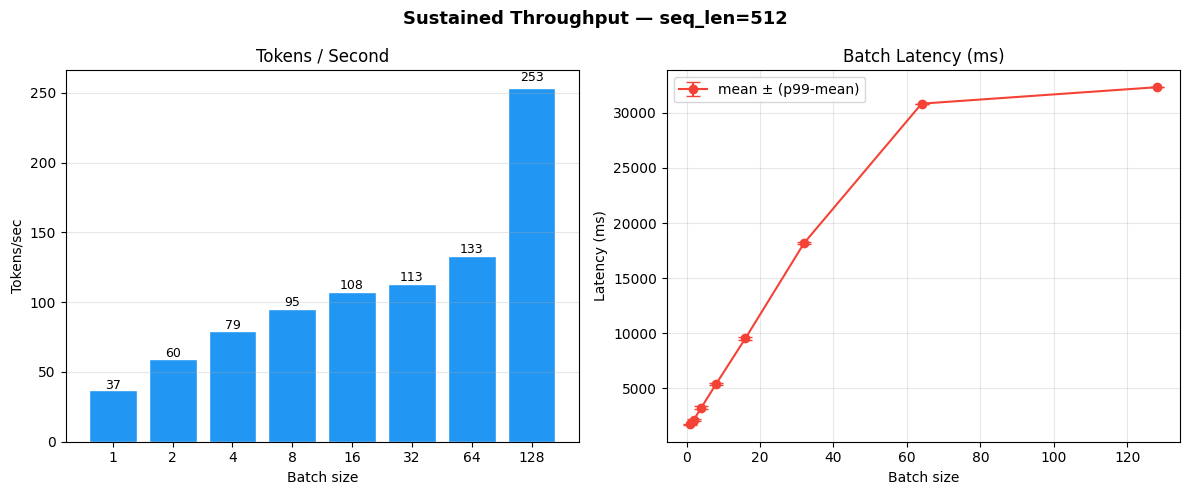

Plots saved to results/plots/throughput_benchmark.png


In [22]:

throughput_results = run_throughput_benchmark(
    decoder       = decoder,
    batch_sizes   = [1, 2, 4, 8, 16, 32, 64, 128],
    seq_len       = 512,
    duration_sec  = 30,
)
plot_throughput_results(throughput_results)

## 9. Roofline Analysis

Roofline plot saved to results/plots/roofline.png


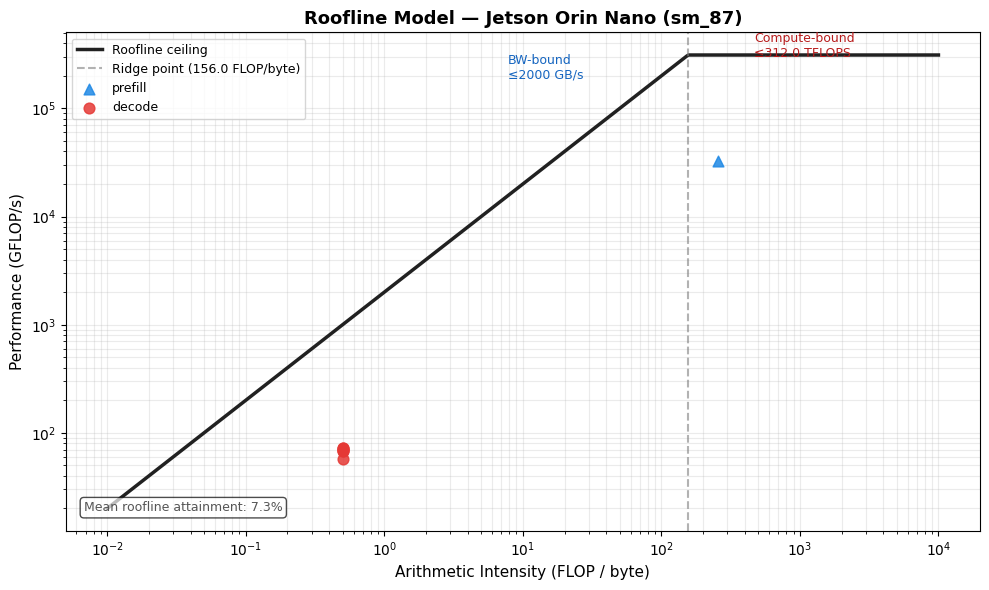


  Roofline Summary  (ridge=156.0 FLOP/byte)
  Phase      Step           AI    Perf(G) Bound          
  -------------------------------------------------------
  prefill    -          257.00   32638.34 Compute-bound  
  decode     0            0.50      68.00 Memory-bound   
  decode     1            0.50      69.37 Memory-bound   
  decode     2            0.50      67.60 Memory-bound   
  decode     3            0.50      56.72 Memory-bound   
  decode     4            0.50      71.50 Memory-bound   
  decode     5            0.50      71.74 Memory-bound   
  decode     6            0.50      72.14 Memory-bound   



In [10]:
heavy_prompt = "Hello " * 512

# 2. Run the decoder once with the heavy prompt to populate the stats array
_ = decoder.generate(heavy_prompt, max_new_tokens=64)
analyzer = RooflineAnalyzer(
    peak_flops_tflops = 312.0,   # A100 FP16 BF16 tensor core peak
    peak_bw_gbps      = 2000.0,  # A100 HBM2e bandwidth
)
kernel_stats = decoder.get_last_kernel_stats()
analyzer.plot_roofline(kernel_stats)
analyzer.summary(kernel_stats)

## 10. KV-Cache Diagnostics

In [11]:
stats = kv_manager.get_stats()
print(f"\nKV-Cache stats after generation:")
print(f"  Blocks allocated : {stats['allocated_blocks']} / {stats['total_blocks']}")
print(f"  Utilisation      : {stats['utilization_pct']:.1f}%")
print(f"  Evictions        : {stats['evictions']}")
print(f"  Peak memory (MB) : {stats['peak_memory_mb']:.1f}")
print(f"  Pool total (MB)  : {stats['pool_total_mb']:.1f}")



KV-Cache stats after generation:
  Blocks allocated : 0 / 2048
  Utilisation      : 0.0%
  Evictions        : 0
  Peak memory (MB) : 103.8
  Pool total (MB)  : 6442.5


In [12]:
stats

{'allocated_blocks': 0,
 'total_blocks': 2048,
 'free_blocks': 2048,
 'utilization_pct': 0.0,
 'evictions': 0,
 'peak_memory_mb': 103.809024,
 'pool_total_mb': 6442.450944,
 'active_sequences': 0}